In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from pathlib import Path
F_DATA = Path('../data/processed')

import sys, os


sys.path.append(os.path.abspath('..'))  


Очистка данных для предмета: МА
План 1:


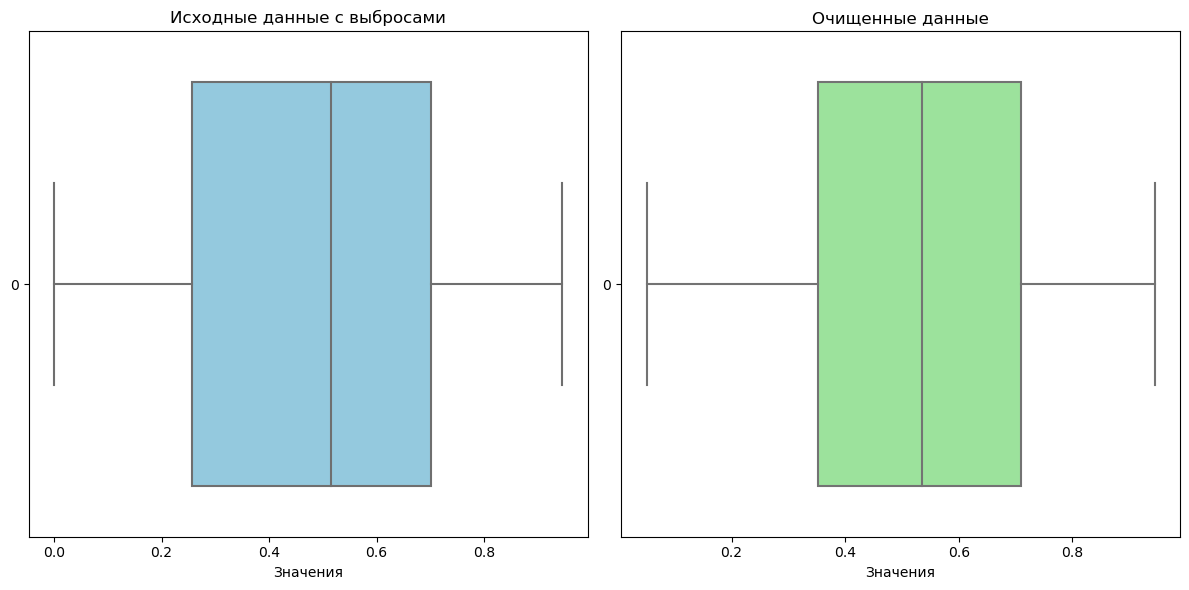

Удалено выбросов: 20
Осталось точек: 123
План 2:


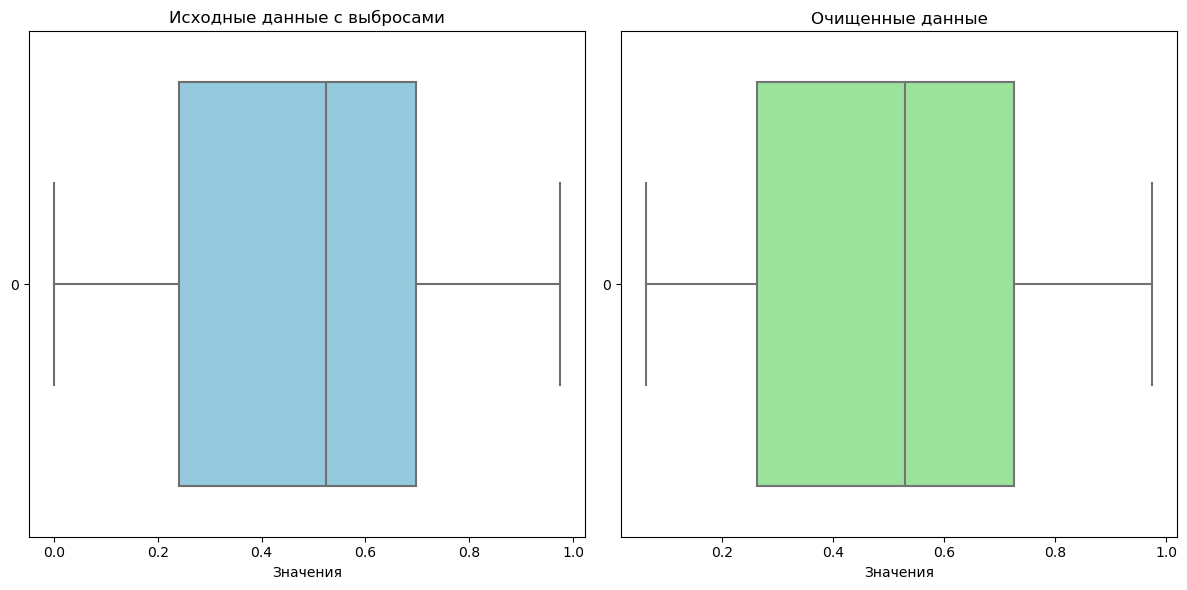

Удалено выбросов: 6
Осталось точек: 137
Предмет МА:
  План 1: 123 записей после очистки
  План 2: 137 записей после очистки

Очистка данных для предмета: СРМА
План 1:


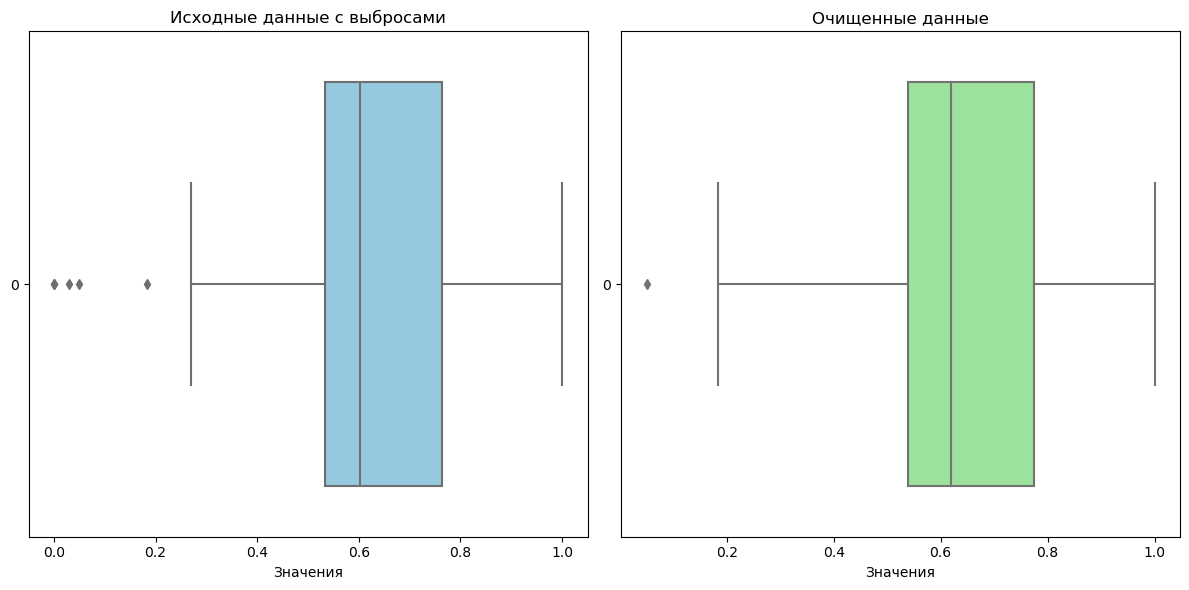

Удалено выбросов: 3
Осталось точек: 77
План 2:


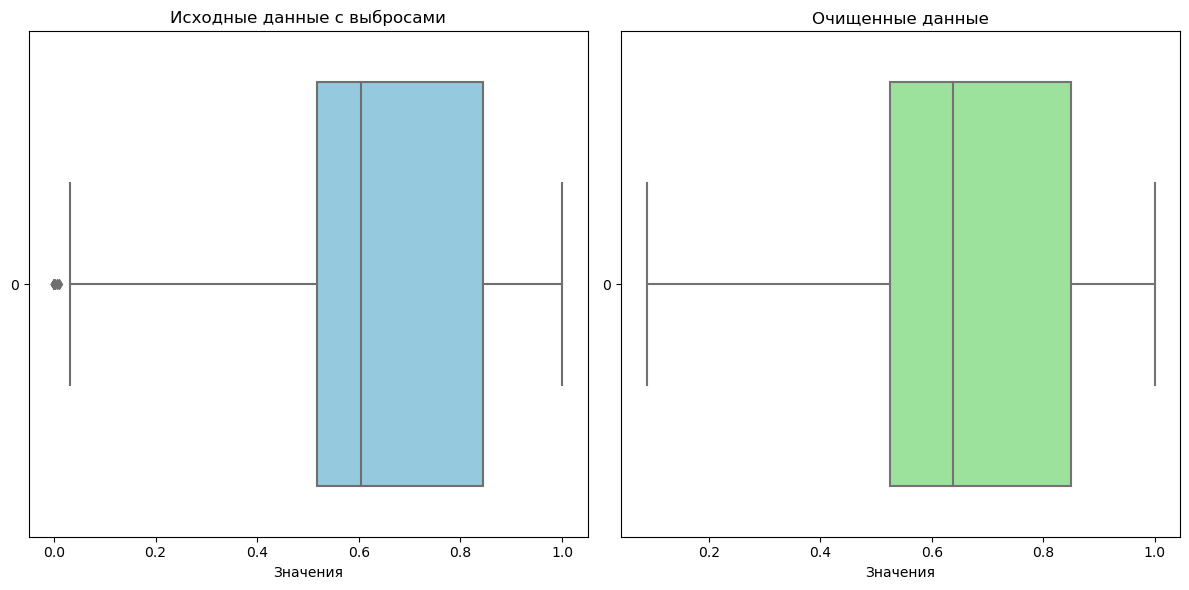

Удалено выбросов: 10
Осталось точек: 144
Предмет СРМА:
  План 1: 77 записей после очистки
  План 2: 144 записей после очистки


In [3]:
from src.iqr import remove_outliers_iqr


df = pd.read_excel(F_DATA / 'final_df.xlsx')
df.columns = ['План', 'Дисц', 'Балл']
df['Балл'] = pd.to_numeric(df['Балл'], errors='coerce')
df = df.dropna(subset=['Балл'])

# Разделяем данные по планам
plan_1_data = df[df['План'] == 1]
plan_2_data = df[df['План'] == 2]

# Список предметов для анализа
subjects = ['МА', 'СРМА']

# Словарь для хранения очищенных данных и статистик
cleaned_scores = {}
stats = {}

# Обрабатываем данные для каждого предмета
for subject in subjects:
    # Извлекаем баллы для Плана 1
    plan_1_scores = plan_1_data[plan_1_data['Дисц'] == subject]['Балл'].to_numpy()
    # Извлекаем баллы для Плана 2
    plan_2_scores = plan_2_data[plan_2_data['Дисц'] == subject]['Балл'].to_numpy()

    # Очищаем данные от выбросов с помощью функции remove_outliers_iqr
    print(f"\nОчистка данных для предмета: {subject}")
    print("План 1:")
    cleaned_plan_1 = remove_outliers_iqr(plan_1_scores, k=1.5, visualize=True)
    print("План 2:")
    cleaned_plan_2 = remove_outliers_iqr(plan_2_scores, k=1.5, visualize=True)

    # Сохраняем очищенные данные в словарь
    cleaned_scores[subject] = {
        'plan_1': cleaned_plan_1.tolist(),
        'plan_2': cleaned_plan_2.tolist()
    }

    # Выводим количество записей после очистки
    print(f"Предмет {subject}:")
    print(f"  План 1: {len(cleaned_plan_1)} записей после очистки")
    print(f"  План 2: {len(cleaned_plan_2)} записей после очистки")

In [4]:
all_stats = {}  

from src.stats import calculate_stats, print_statistics
for subject in subjects:
    plan_1_scores = np.array(cleaned_scores[subject]['plan_1'])
    plan_2_scores = np.array(cleaned_scores[subject]['plan_2'])
    all_stats[subject] = calculate_stats(plan_1_scores, plan_2_scores)
    
print_statistics(all_stats, subjects)

 СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ

 Предмет: МА
------------------------------
План 1:
  Объем выборки: 123
  Медиана: 0.536
  Дисперсия: 0.05435
  Асимметрия: -0.33746
  Среднее: 0.5378
План 2:
  Объем выборки: 137
  Медиана: 0.529
  Дисперсия: 0.06482
  Асимметрия: 0.01374
  Среднее: 0.4944

 Предмет: СРМА
------------------------------
План 1:
  Объем выборки: 77
  Медиана: 0.620
  Дисперсия: 0.03609
  Асимметрия: -0.33694
  Среднее: 0.6405
План 2:
  Объем выборки: 144
  Медиана: 0.638
  Дисперсия: 0.05973
  Асимметрия: -0.38235
  Среднее: 0.6512



Построение гистограмм для предмета: МА


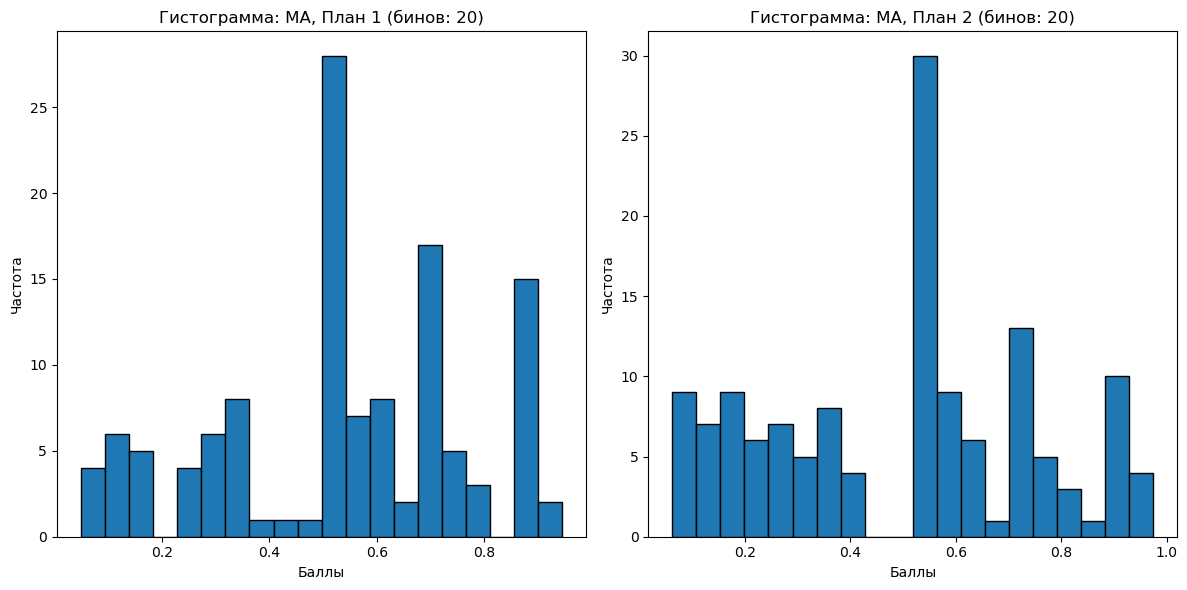


Построение гистограмм для предмета: СРМА


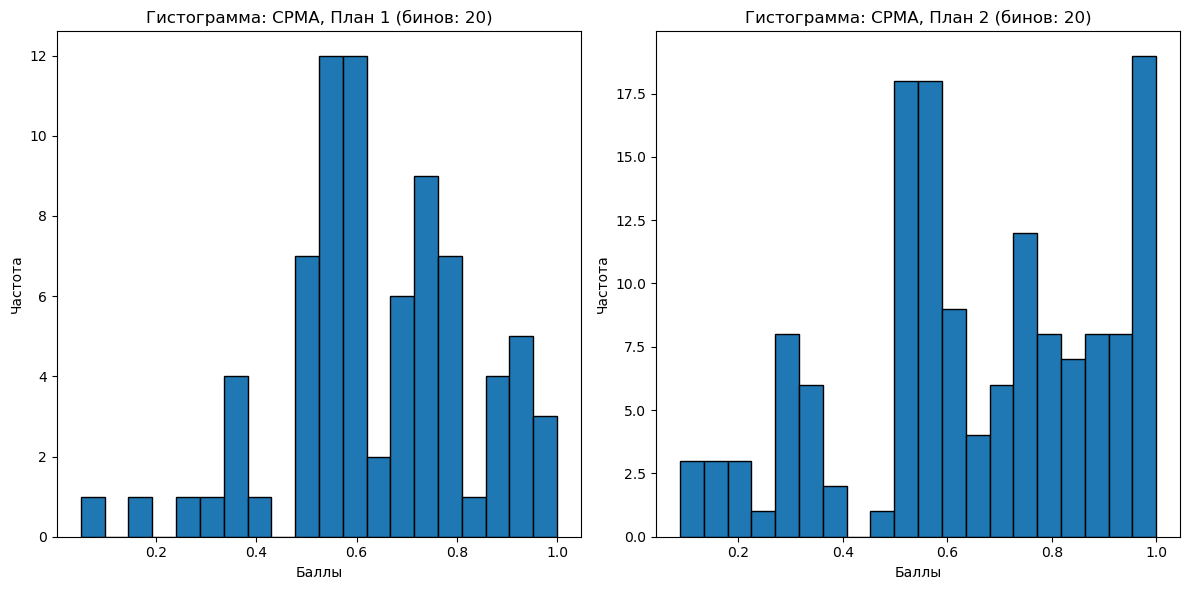

In [16]:
# Построение гистограмм для очищенных данных с количеством бинов по правилу Стерджеса
for subject in subjects:
    print(f"\nПостроение гистограмм для предмета: {subject}")

    # Проверяем наличие данных для предмета в cleaned_scores
    if subject not in cleaned_scores:
        print(f"  Данные для предмета {subject} отсутствуют в cleaned_scores.")
        continue

    # Извлекаем очищенные данные для Плана 1 и Плана 2
    plan_1_scores = np.array(cleaned_scores[subject]['plan_1'])
    plan_2_scores = np.array(cleaned_scores[subject]['plan_2'])

    # Проверяем, есть ли данные для построения гистограмм
    if len(plan_1_scores) == 0 and len(plan_2_scores) == 0:
        print(f"  Нет данных для Плана 1 и Плана 2 после очистки.")
        continue

    # Создаем фигуру для гистограмм
    plt.figure(figsize=(12, 6))

    # Гистограмма для Плана 1
    if len(plan_1_scores) > 0:
        bins_1 = 20
        plt.subplot(1, 2, 1)
        plt.hist(plan_1_scores, bins=bins_1, edgecolor='black')
        plt.title(f"Гистограмма: {subject}, План 1 (бинов: {bins_1})")
        plt.xlabel("Баллы")
        plt.ylabel("Частота")
    else:
        print("  План 1: Нет данных после очистки.")

    # Гистограмма для Плана 2
    if len(plan_2_scores) > 0:
        bins_2 = 20
        plt.subplot(1, 2, 2)
        plt.hist(plan_2_scores, bins=bins_2, edgecolor='black')
        plt.title(f"Гистограмма: {subject}, План 2 (бинов: {bins_2})")
        plt.xlabel("Баллы")
        plt.ylabel("Частота")
    else:
        print("  План 2: Нет данных после очистки.")

    # Улучшаем компоновку и отображаем графики
    plt.tight_layout()
    plt.show()

In [ ]:
# Добавил бутстреп - тест как более подходящий для анализа мат ожидания несимметричных распределений


from src import tests

for subject in subjects:
    print(f"\nБутстреп тест для предмета: {subject}")
    if not subject=="ТВиМС":
        p_value = tests.bootstrap_mean_diff_test(plan_1_scores, plan_2_scores)
    else:
        p_value = tests.bootstrap_mean_diff_test(plan_1_scores, plan_2_scores, alternative='less')

    print(f"  p-значение: {p_value:.5f}")
    # Извлекаем очищенные данные для Плана 1 и Плана 2
    plan_1_scores = np.array(cleaned_scores[subject]['plan_1'])
    plan_2_scores = np.array(cleaned_scores[subject]['plan_2'])
    # Интерпретация результатов
    alpha = 0.05  # Уровень значимости
    if p_value < alpha:
        print(f"  Результат: p < {alpha}, отвергаем H₀. Математические ожидания баллов для Плана 1 и Плана 2 различаются.")
    else:
        print(f"  Результат: p >= {alpha}, не отвергаем H₀. Нет достаточных оснований считать, что математические ожидания баллов различаются.")



Бутстреп тест для предмета: МА
  p-значение: 0.73969
  Результат: p >= 0.05, не отвергаем H₀. Нет достаточных оснований считать, что математические ожидания баллов различаются.

Бутстреп тест для предмета: СРМА
  p-значение: 0.15182
  Результат: p >= 0.05, не отвергаем H₀. Нет достаточных оснований считать, что математические ожидания баллов различаются.


In [18]:
import numpy as np
from scipy.stats import norm

# Анализ несдавших и сравнение вероятностей с помощью Z-теста
for subject in subjects:
    print(f"\nАнализ несдавших для предмета: {subject}")

    # Проверяем наличие данных для предмета в cleaned_scores
    if subject not in cleaned_scores:
        print(f"  Данные для предмета {subject} отсутствуют в cleaned_scores.")
        continue

    # Извлекаем очищенные данные для Плана 1 и Плана 2
    plan_1_scores = np.array(cleaned_scores[subject]['plan_1'])
    plan_2_scores = np.array(cleaned_scores[subject]['plan_2'])

    # Подсчитываем количество несдавших (балл < 0.5) и общее число студентов
    non_passing_plan_1 = np.sum(plan_1_scores < 0.5)
    total_plan_1 = len(plan_1_scores)
    non_passing_plan_2 = np.sum(plan_2_scores < 0.5)
    total_plan_2 = len(plan_2_scores)

    # Вычисляем вероятности не сдать
    prob_non_passing_plan_1 = non_passing_plan_1 / total_plan_1 if total_plan_1 > 0 else np.nan
    prob_non_passing_plan_2 = non_passing_plan_2 / total_plan_2 if total_plan_2 > 0 else np.nan

    # Выводим результаты подсчета
    print("  План 1:")
    print(f"    Несдавших (балл < 0.5): {non_passing_plan_1} из {total_plan_1}")
    print(f"    Вероятность не сдать: {prob_non_passing_plan_1:.4f}" if not np.isnan(prob_non_passing_plan_1) else "    Вероятность не сдать: нет данных")
    print("  План 2:")
    print(f"    Несдавших (балл < 0.5): {non_passing_plan_2} из {total_plan_2}")
    print(f"    Вероятность не сдать: {prob_non_passing_plan_2:.4f}" if not np.isnan(prob_non_passing_plan_2) else "    Вероятность не сдать: нет данных")

    # Проверяем, можно ли выполнить Z-тест
    if total_plan_1 < 5 or total_plan_2 < 5 or non_passing_plan_1 == 0 or non_passing_plan_2 == 0:
        print("  Z-тест не выполнен: недостаточно данных или несдавших (требуется минимум 5 наблюдений и хотя бы 1 несдавший в каждой выборке).")
        continue

    # Выполняем Z-тест
    z_stat, p_value = tests.z_test_proportions(non_passing_plan_1, total_plan_1, non_passing_plan_2, total_plan_2)

    # Выводим результаты Z-теста
    if not np.isnan(z_stat):
        print(f"  Z-тест для сравнения вероятностей:")
        print(f"    Статистика Z: {z_stat:.2f}")
        print(f"    p-значение: {p_value:.4f}")

        # Интерпретация результатов
        alpha = 0.05  # Уровень значимости
        if p_value < alpha:
            print(f"    Результат: p < {alpha}, отвергаем H₀. Вероятности не сдать для Плана 1 и Плана 2 различаются.")
        else:
            print(f"    Результат: p >= {alpha}, не отвергаем H₀. Нет достаточных оснований считать, что вероятности не сдать различаются.")
    else:
        print("  Z-тест не выполнен: невозможно вычислить пропорции (например, нет несдавших).")


Анализ несдавших для предмета: МА
  План 1:
    Несдавших (балл < 0.5): 36 из 123
    Вероятность не сдать: 0.2927
  План 2:
    Несдавших (балл < 0.5): 55 из 137
    Вероятность не сдать: 0.4015
  Z-тест для сравнения вероятностей:
    Статистика Z: -1.84
    p-значение: 0.0664
    Результат: p >= 0.05, не отвергаем H₀. Нет достаточных оснований считать, что вероятности не сдать различаются.

Анализ несдавших для предмета: СРМА
  План 1:
    Несдавших (балл < 0.5): 9 из 77
    Вероятность не сдать: 0.1169
  План 2:
    Несдавших (балл < 0.5): 27 из 144
    Вероятность не сдать: 0.1875
  Z-тест для сравнения вероятностей:
    Статистика Z: -1.35
    p-значение: 0.1756
    Результат: p >= 0.05, не отвергаем H₀. Нет достаточных оснований считать, что вероятности не сдать различаются.


In [19]:
for subject in subjects:
    plan_1_scores = np.array(cleaned_scores[subject]['plan_1'])
    plan_2_scores = np.array(cleaned_scores[subject]['plan_2'])
    gooder_plan_1 = np.sum(plan_1_scores >= 0.7)
    gooder_plan_2 = np.sum(plan_2_scores >= 0.7)
    total_plan_1 = len(plan_1_scores)
    total_plan_2 = len(plan_2_scores)

    print(subject)
    print("  План 1:")
    print(f"    Хорошистов и отличников (балл >= 0.7): {gooder_plan_1} из {total_plan_1}")
    print(f"    Вероятность получить хорошую оценку: {(gooder_plan_1 / total_plan_1):.4f}")
    print("  План 2:")
    print(f"    Хорошистов и отличников (балл >= 0.7): {gooder_plan_2} из {total_plan_2}")
    print(f"    Вероятность получить хорошую оценку: {(gooder_plan_2 / total_plan_2):.4f}")


    z_stat_2, p_value_2 = tests.z_test_proportions(gooder_plan_1, total_plan_1, gooder_plan_2, total_plan_2)
    if not np.isnan(z_stat):
        print(f"  Z-тест для сравнения вероятностей:")
        print(f"    Статистика Z: {z_stat_2:.2f}")
        print(f"    p-значение: {p_value_2:.4f}")

        # Интерпретация результатов
        alpha = 0.05  # Уровень значимости
        if p_value_2 < alpha:
            print(f"    Результат: p < {alpha}, отвергаем H₀. Вероятности получить хорошую оценку для Плана 1 и Плана 2 различаются.\n")
        else:
            print(f"    Результат: p >= {alpha}, не отвергаем H₀. Нет достаточных оснований считать, что вероятности получить хорошую оценку различаются.\n")

МА
  План 1:
    Хорошистов и отличников (балл >= 0.7): 42 из 123
    Вероятность получить хорошую оценку: 0.3415
  План 2:
    Хорошистов и отличников (балл >= 0.7): 36 из 137
    Вероятность получить хорошую оценку: 0.2628
  Z-тест для сравнения вероятностей:
    Статистика Z: 1.38
    p-значение: 0.1668
    Результат: p >= 0.05, не отвергаем H₀. Нет достаточных оснований считать, что вероятности получить хорошую оценку различаются.

СРМА
  План 1:
    Хорошистов и отличников (балл >= 0.7): 31 из 77
    Вероятность получить хорошую оценку: 0.4026
  План 2:
    Хорошистов и отличников (балл >= 0.7): 67 из 144
    Вероятность получить хорошую оценку: 0.4653
  Z-тест для сравнения вероятностей:
    Статистика Z: -0.89
    p-значение: 0.3715
    Результат: p >= 0.05, не отвергаем H₀. Нет достаточных оснований считать, что вероятности получить хорошую оценку различаются.



In [20]:
# проверяется гипотеза о равенстве дисперсий для СРМА

from scipy.stats import levene
_, p_value = levene(cleaned_scores["СРМА"]['plan_1'], cleaned_scores["СРМА"]['plan_2'])
print(f"p = {p_value}")
print('Дисперсии значимо различаются (p < 0.05)')

p = 0.0037650219015699705
Дисперсии значимо различаются (p < 0.05)


In [2]:
from scipy.stats import levene
_, p_value = levene(cleaned_scores["МА"]['plan_1'], cleaned_scores["МА"]['plan_2'])
print(f"p = {p_value}")


p = 0.20759791522558588
Дисперсии значимо различаются (p < 0.05)


Дисперсии значимо различаются (p < 0.05)

#### Вывод:

**МА:** Статистические методы показали незначительно лучшее усвоение материала в первой группе, по сравнению со второй МА. Но следует отметить, что не были учтены студенты, получившие менее 5 баллов (мы считаем их неприступившими к учебе или бросившими ее), а их значительно больше в первой группе 20 против 6 из второй группы. С учетом данных студентов ситуация выравнивается

**СРМА:** В изучении данного предмета несколько лучше себя показали обучающиеся по первому плану (вероятность получения неудовлетворительной оценки меньше чем 2 раза). Парадоксально, что вторая группа показывает несколько лучшие результаты у успевающих студентов. Они хоть и не являются статистически значимыми, тем не менее это возможно указывает на небольшую *поляризацию в группе: сильные студенты выигрывают от плана, а слабые — проигрывают.* Что подтверждается также тем, что у второй группы дисперсия распределения баллов значительно больше, чем у первой